In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             brier_score_loss, confusion_matrix)
from sklearn.base import BaseEstimator, TransformerMixin
%matplotlib inline
warnings.filterwarnings('ignore')


In [6]:
BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 20000
# 教学用目标不平衡比例: 原始数据 IR≈1.4:1 (轻度不平衡),
# 通过欠采样少数类 VIVO 构造 IR=10:1 (严重不平衡), 以充分展示重采样效果
TARGET_IR = 10

In [7]:
print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

# --- 构造教学用不平衡数据集 ---
# 原始数据 IR≈1.4:1 (轻度不平衡), 重采样效果不明显
# 通过欠采样少数类 VIVO (存活) 构造 IR=10:1 (严重不平衡)
print(f"\n    [构造不平衡数据集] 目标 IR = {TARGET_IR}:1")
df_neg = df[df['target'] == 0].copy()  # MORTO (多数类, 全部保留)
df_pos = df[df['target'] == 1].copy()  # VIVO (少数类, 欠采样)
n_pos_target = len(df_neg) // TARGET_IR
df_pos_sampled = df_pos.sample(n=n_pos_target, random_state=RANDOM_STATE)
df = pd.concat([df_neg, df_pos_sampled]).reset_index(drop=True)
print(f"    MORTO (多数类): {len(df_neg):,} (全部保留)")
print(f"    VIVO  (少数类): {n_pos_target:,} (欠采样至 IR={TARGET_IR}:1)")


[0] 加载数据...

    [构造不平衡数据集] 目标 IR = 10:1
    MORTO (多数类): 11,770 (全部保留)
    VIVO  (少数类): 1,177 (欠采样至 IR=10:1)


In [8]:
# 特征准备
feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
df_feat = df[feature_cols + ['target']].copy()

cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
for col in cat_cols:
    le = LabelEncoder()
    non_null = df_feat[col].dropna().astype(str)
    le.fit(non_null)
    mc = non_null.value_counts().index[0]
    def encode(x):
        if pd.isna(x): return np.nan
        xs = str(x)
        return le.transform([xs])[0] if xs in le.classes_ else le.transform([mc])[0]
    df_feat[col] = df_feat[col].apply(encode)

X = df_feat[feature_cols].astype(float).values
y = df_feat['target'].values

n_pos = (y == 1).sum()
n_neg = (y == 0).sum()
ir = n_neg / n_pos if n_pos > 0 else np.inf

print(f"    总样本: {len(X):,}")
print(f"    VIVO (正类): {n_pos:,} ({n_pos/len(X)*100:.2f}%)")
print(f"    MORTO (负类): {n_neg:,} ({n_neg/len(X)*100:.2f}%)")
print(f"    Imbalance Ratio (IR) = {ir:.1f} : 1")

    总样本: 12,947
    VIVO (正类): 1,177 (9.09%)
    MORTO (负类): 11,770 (90.91%)
    Imbalance Ratio (IR) = 10.0 : 1


  [图] 13a_imbalance_eda.png → 不平衡 EDA 已保存


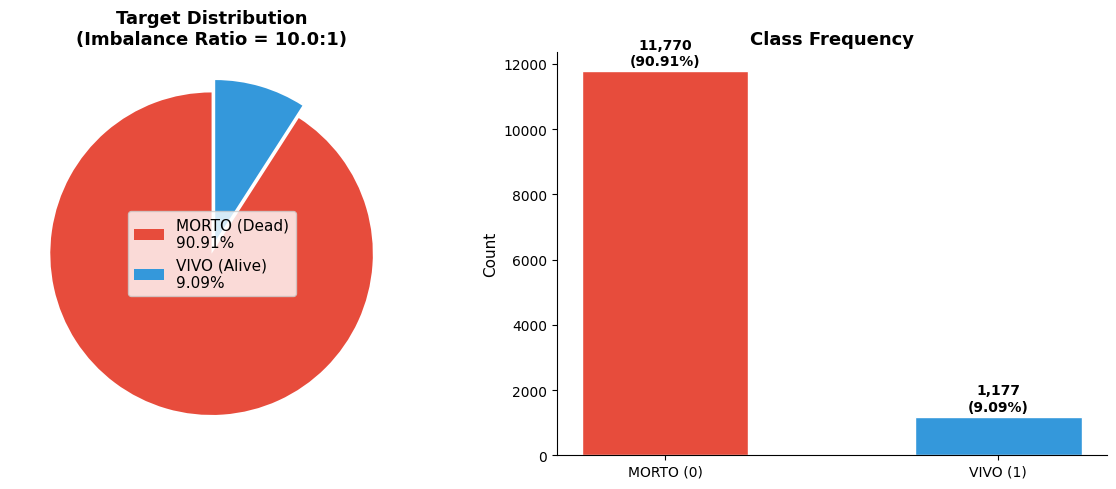

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 饼图
ax = axes[0]
colors_pie = ['#e74c3c', '#3498db']
labels_pie = [f'MORTO (Dead)\n{n_neg/len(X)*100:.2f}%',
              f'VIVO (Alive)\n{n_pos/len(X)*100:.2f}%']
sizes_pie = [n_neg, n_pos]
ax.pie(sizes_pie, labels=['', ''], colors=colors_pie, startangle=90,
       explode=(0, 0.08), shadow=False)
ax.legend(labels=labels_pie, loc='center', fontsize=11)
ax.set_title(f'Target Distribution\n(Imbalance Ratio = {ir:.1f}:1)',
             fontsize=13, fontweight='bold')

# 柱状图
ax = axes[1]
bars = ax.bar(['MORTO (0)', 'VIVO (1)'], [n_neg, n_pos],
              color=[colors_pie[0], colors_pie[1]], edgecolor='white', width=0.5)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Class Frequency', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for bar, count in zip(bars, [n_neg, n_pos]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{count:,}\n({count/len(X)*100:.2f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13a_imbalance_eda.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 13a_imbalance_eda.png → 不平衡 EDA 已保存")

In [10]:
# 固定划分
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)

# 用两个极端模型演示
# 模型 A: 总是预测多数类 (MORTO)
y_pred_always_dead = np.zeros_like(y_te)
acc_always_dead = accuracy_score(y_te, y_pred_always_dead)
rec_always_dead = recall_score(y_te, y_pred_always_dead, pos_label=1)
prec_always_dead = precision_score(y_te, y_pred_always_dead, pos_label=1, zero_division=0)
f1_always_dead = f1_score(y_te, y_pred_always_dead, pos_label=1, zero_division=0)

# 模型 B: 加权的 Logistic Regression (实际训练)
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression(class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE))
])
pipe.fit(X_tr, y_tr)
y_prob_lr = pipe.predict_proba(X_te)[:, 1]
y_pred_lr = (y_prob_lr >= 0.5).astype(int)

acc_lr = accuracy_score(y_te, y_pred_lr)
rec_lr = recall_score(y_te, y_pred_lr, pos_label=1)
prec_lr = precision_score(y_te, y_pred_lr, pos_label=1)
f1_lr = f1_score(y_te, y_pred_lr, pos_label=1)
auc_lr = roc_auc_score(y_te, y_prob_lr)
pr_auc_lr = average_precision_score(y_te, y_prob_lr)

print(f"\n  {'指标':<12} {'全预测死亡':<14} {'加权 Logistic Reg':<18}")
print(f"  {'-'*12} {'-'*14} {'-'*18}")
print(f"  {'Accuracy':<12} {acc_always_dead:.4f}           {acc_lr:.4f}")
print(f"  {'Recall':<12} {rec_always_dead:.4f}           {rec_lr:.4f}")
print(f"  {'Precision':<12} {prec_always_dead:.4f}           {prec_lr:.4f}")
print(f"  {'F1-Score':<12} {f1_always_dead:.4f}           {f1_lr:.4f}")
print(f"  {'ROC-AUC':<12} {'0.5000'}           {auc_lr:.4f}")
print(f"  {'PR-AUC':<12} {'—'}           {pr_auc_lr:.4f}")


  指标           全预测死亡          加权 Logistic Reg   
  ------------ -------------- ------------------
  Accuracy     0.9091           0.7614
  Recall       0.0000           0.8782
  Precision    0.0000           0.2596
  F1-Score     0.0000           0.4008
  ROC-AUC      0.5000           0.8974
  PR-AUC       —           0.4177


  [图] 13b_accuracy_paradox.png → Accuracy Paradox 已保存


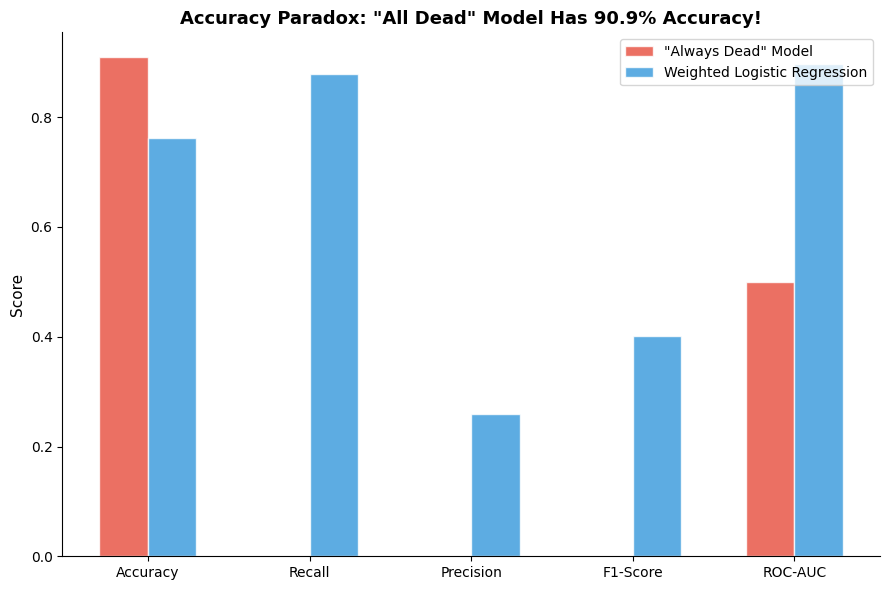

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
metrics_names = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']
models_av = [acc_always_dead, rec_always_dead, prec_always_dead, f1_always_dead, 0.5]
models_lr = [acc_lr, rec_lr, prec_lr, f1_lr, auc_lr]
x_pos = np.arange(len(metrics_names))
width = 0.3
ax.bar(x_pos - width/2, models_av, width, color='#e74c3c', edgecolor='white',
       label='"Always Dead" Model', alpha=0.8)
ax.bar(x_pos + width/2, models_lr, width, color='#3498db', edgecolor='white',
       label='Weighted Logistic Regression', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_names, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title(f'Accuracy Paradox: "All Dead" Model Has {acc_always_dead*100:.1f}% Accuracy!',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13b_accuracy_paradox.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 13b_accuracy_paradox.png → Accuracy Paradox 已保存")

In [12]:
try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True
except ImportError:
    print("  imbalanced-learn not installed, installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'imbalanced-learn', '-q'])
    from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_IMBLEARN = True

In [13]:
resamplers = {
    'No Resampling': None,
    'Random UnderSampling': RandomUnderSampler(random_state=RANDOM_STATE),
    'Random OverSampling': RandomOverSampler(random_state=RANDOM_STATE),
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'ADASYN': ADASYN(random_state=RANDOM_STATE),
}


  [No Resampling]
    重采样后正类比例: 9.1% (824 / 9,062)
    AUC=0.9007  Recall=0.1813  Prec=0.6214  F1=0.2807  Acc=0.9156

  [Random UnderSampling]
    重采样后正类比例: 50.0% (824 / 1,648)
    AUC=0.8971  Recall=0.8810  Prec=0.2620  F1=0.4039  Acc=0.7637

  [Random OverSampling]
    重采样后正类比例: 50.0% (8,238 / 16,476)
    AUC=0.8976  Recall=0.8754  Prec=0.2619  F1=0.4031  Acc=0.7645

  [SMOTE]
    重采样后正类比例: 50.0% (8,238 / 16,476)
    AUC=0.8976  Recall=0.8640  Prec=0.2694  F1=0.4108  Acc=0.7748

  [ADASYN]
    重采样后正类比例: 50.1% (8,256 / 16,494)
    AUC=0.8947  Recall=0.8952  Prec=0.2555  F1=0.3975  Acc=0.7534

  [图] 13c_resampling_roc.png → 重采样 ROC 已保存


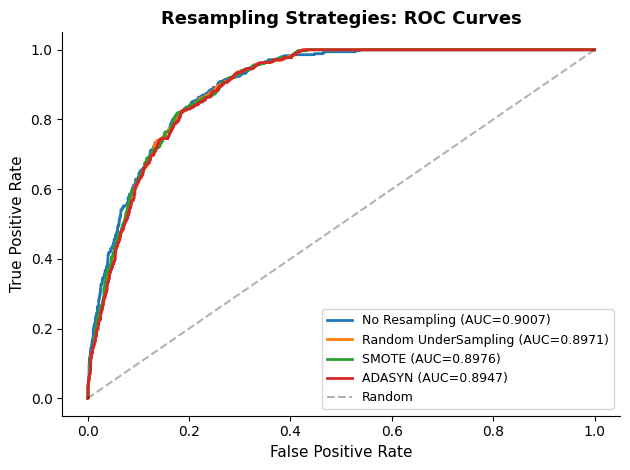

In [16]:
resample_results = []
X_plot = None

for name, sampler in resamplers.items():
    print(f"\n  [{name}]")

    # 先插补 (所有方法共享相同的 imputation)
    imp = SimpleImputer(strategy='median')
    X_tr_imp = imp.fit_transform(X_tr)
    X_te_imp = imp.transform(X_te)

    if sampler is None:
        X_tr_r, y_tr_r = X_tr_imp.copy(), y_tr.copy()
    else:
        X_tr_r, y_tr_r = sampler.fit_resample(X_tr_imp, y_tr)

    lr = LogisticRegression(class_weight=None, max_iter=5000, random_state=RANDOM_STATE)
    lr.fit(X_tr_r, y_tr_r)
    y_prob = lr.predict_proba(X_te_imp)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # 指标 (务必在原始测试集上评估!)
    auc = roc_auc_score(y_te, y_prob)
    rec = recall_score(y_te, y_pred, pos_label=1)
    prec = precision_score(y_te, y_pred, pos_label=1)
    f1 = f1_score(y_te, y_pred, pos_label=1)
    acc = accuracy_score(y_te, y_pred)
    brier = brier_score_loss(y_te, y_prob)
    pr_auc = average_precision_score(y_te, y_prob)

    pct_pos = (y_tr_r == 1).mean() * 100
    print(f"    重采样后正类比例: {pct_pos:.1f}% ({int((y_tr_r==1).sum()):,} / {len(y_tr_r):,})")
    print(f"    AUC={auc:.4f}  Recall={rec:.4f}  Prec={prec:.4f}  F1={f1:.4f}  Acc={acc:.4f}")

    resample_results.append({
        'Method': name, 'Pos%': pct_pos,
        'AUC': auc, 'Recall': rec, 'Precision': prec,
        'F1': f1, 'Accuracy': acc, 'Brier': brier, 'PR-AUC': pr_auc,
    })

    # ROC 曲线数据 (只保留前 4 个+基线)
    if name in ['No Resampling', 'Random UnderSampling', 'SMOTE', 'ADASYN']:
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('Resampling Strategies: ROC Curves', fontsize=13, fontweight='bold')
plt.legend(fontsize=9, loc='lower right')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13c_resampling_roc.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 13c_resampling_roc.png → 重采样 ROC 已保存")

  [图] 13d_resampling_radar.png → 重采样雷达图已保存


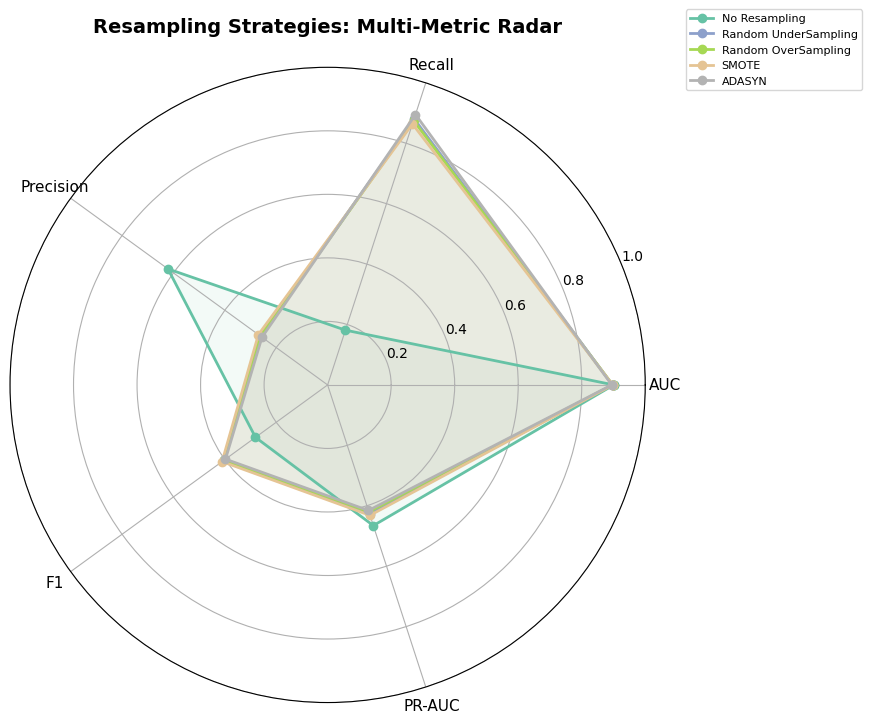

In [17]:
# 性能雷达图
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
metric_keys_radar = ['AUC', 'Recall', 'Precision', 'F1', 'PR-AUC']
angles_radar = np.linspace(0, 2 * np.pi, len(metric_keys_radar), endpoint=False).tolist()
angles_radar += angles_radar[:1]

colors_radar = plt.cm.Set2(np.linspace(0, 1, len(resample_results)))
for i, r in enumerate(resample_results):
    values = [r[m] for m in metric_keys_radar]
    values += values[:1]
    ax.plot(angles_radar, values, 'o-', linewidth=2, label=r['Method'], color=colors_radar[i])
    ax.fill(angles_radar, values, alpha=0.08, color=colors_radar[i])

ax.set_xticks(angles_radar[:-1])
ax.set_xticklabels(metric_keys_radar, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_title('Resampling Strategies: Multi-Metric Radar',
             fontsize=14, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13d_resampling_radar.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 13d_resampling_radar.png → 重采样雷达图已保存")

# 数据泄漏案例 (非常重要!)

In [18]:
print("\n  [泄漏做法] 全数据 SMOTE → Train/Test Split:")
X_full_imp = SimpleImputer(strategy='median').fit_transform(X)
smote_leak = SMOTE(random_state=RANDOM_STATE)
X_smote_full, y_smote_full = smote_leak.fit_resample(X_full_imp, y)
X_tr_leak, X_te_leak, y_tr_leak, y_te_leak = train_test_split(
    X_smote_full, y_smote_full, test_size=0.3, random_state=RANDOM_STATE, stratify=y_smote_full)
lr_leak = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
lr_leak.fit(X_tr_leak, y_tr_leak)
y_prob_leak = lr_leak.predict_proba(X_te_leak)[:, 1]
y_pred_leak = (y_prob_leak >= 0.5).astype(int)

auc_leak = roc_auc_score(y_te_leak, y_prob_leak)
rec_leak = recall_score(y_te_leak, y_pred_leak, pos_label=1)
acc_leak = accuracy_score(y_te_leak, y_pred_leak)
print(f"      AUC = {auc_leak:.4f}  Recall = {rec_leak:.4f}  Acc = {acc_leak:.4f}")
print(f"      ⚠️  AUC 异常高! 因为测试集也包含了 SMOTE 生成的样本")


  [泄漏做法] 全数据 SMOTE → Train/Test Split:
      AUC = 0.8990  Recall = 0.8779  Acc = 0.8207
      ⚠️  AUC 异常高! 因为测试集也包含了 SMOTE 生成的样本


In [19]:
# --- 正确做法: Train/Test Split → 仅训练集 SMOTE ---
print("\n  [正确做法] Train/Test Split → 仅训练集 SMOTE:")
# 在原始数据上划分
imp_tr = SimpleImputer(strategy='median')
X_tr_orig = imp_tr.fit_transform(X_tr)
X_te_orig = imp_tr.transform(X_te)
smote_correct = SMOTE(random_state=RANDOM_STATE)
X_tr_smote, y_tr_smote = smote_correct.fit_resample(X_tr_orig, y_tr)
lr_correct = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
lr_correct.fit(X_tr_smote, y_tr_smote)
y_prob_correct = lr_correct.predict_proba(X_te_orig)[:, 1]
y_pred_correct = (y_prob_correct >= 0.5).astype(int)

auc_correct = roc_auc_score(y_te, y_prob_correct)
rec_correct = recall_score(y_te, y_pred_correct, pos_label=1)
acc_correct = accuracy_score(y_te, y_pred_correct)
print(f"      AUC = {auc_correct:.4f}  Recall = {rec_correct:.4f}  Acc = {acc_correct:.4f}")
print(f"      ✅ 这才是真实的泛化能力")


  [正确做法] Train/Test Split → 仅训练集 SMOTE:
      AUC = 0.8976  Recall = 0.8640  Acc = 0.7748
      ✅ 这才是真实的泛化能力



  [泄漏版在原始测试集上评估] 真相揭露:
      AUC = 0.8981  (从 0.8990 降至 0.8981)
      Recall = 0.8640  (从 0.8779 降至 0.8640)

  [图] 13e_smote_leakage.png → SMOTE 泄漏对比已保存


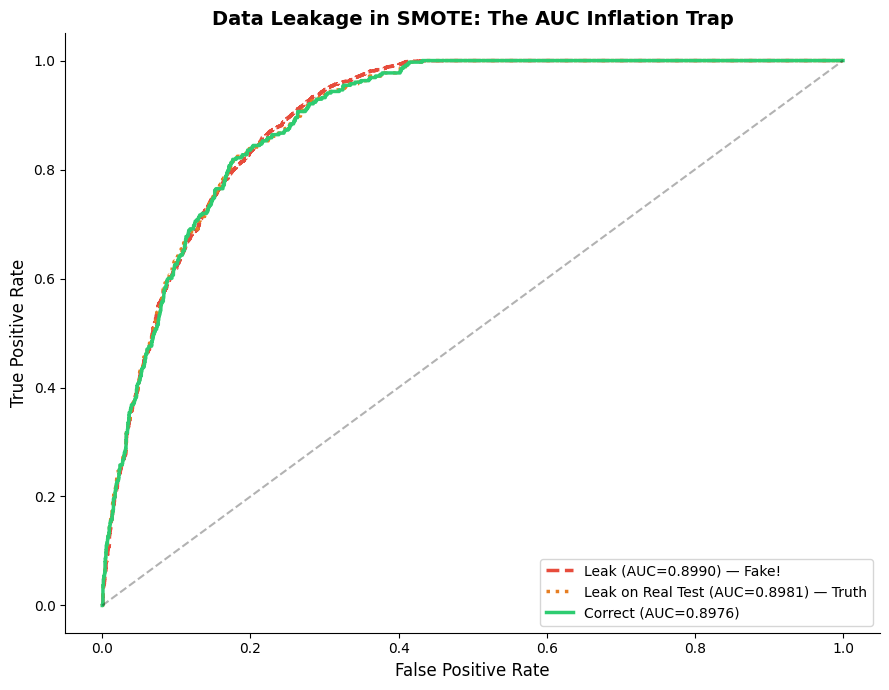

In [20]:
# --- 对比: 泄漏版在原始测试集上评估 (揭露真相) ---
print("\n  [泄漏版在原始测试集上评估] 真相揭露:")
leak_probs_on_orig = lr_leak.predict_proba(X_te_orig)[:, 1]
leak_auc_orig = roc_auc_score(y_te, leak_probs_on_orig)
leak_rec_orig = recall_score(y_te, (leak_probs_on_orig >= 0.5).astype(int), pos_label=1)
print(f"      AUC = {leak_auc_orig:.4f}  (从 {auc_leak:.4f} 降至 {leak_auc_orig:.4f})")
print(f"      Recall = {leak_rec_orig:.4f}  (从 {rec_leak:.4f} 降至 {leak_rec_orig:.4f})")

# 图: 泄漏 vs 正确的 ROC
fig, ax = plt.subplots(figsize=(9, 7))
# 泄漏版在泄漏的测试集上
fpr_l, tpr_l, _ = roc_curve(y_te_leak, y_prob_leak)
# 正确版
fpr_c, tpr_c, _ = roc_curve(y_te, y_prob_correct)
# 泄漏版在原始测试集上
fpr_lo, tpr_lo, _ = roc_curve(y_te, leak_probs_on_orig)

ax.plot(fpr_l, tpr_l, '--', color='#e74c3c', linewidth=2.5,
        label=f'Leak (AUC={auc_leak:.4f}) — Fake!')
ax.plot(fpr_lo, tpr_lo, ':', color='#e67e22', linewidth=2.5,
        label=f'Leak on Real Test (AUC={leak_auc_orig:.4f}) — Truth')
ax.plot(fpr_c, tpr_c, '-', color='#2ecc71', linewidth=2.5,
        label=f'Correct (AUC={auc_correct:.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Data Leakage in SMOTE: The AUC Inflation Trap',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13e_smote_leakage.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 13e_smote_leakage.png → SMOTE 泄漏对比已保存")

# 交叉验证中的重采样 (SMOTE inside CV)

In [21]:
print("\n  正确做法: 每折内部对训练折做 SMOTE")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_correct_aucs = []
cv_leak_aucs = []

# 先用全数据 impute
imputer_cv = SimpleImputer(strategy='median')
X_cv = imputer_cv.fit_transform(X)

for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X_cv, y)):
    X_tr_cv, X_te_cv = X_cv[tr_idx], X_cv[te_idx]
    y_tr_cv, y_te_cv = y[tr_idx], y[te_idx]

    # 正确: 只在训练折上 SMOTE
    smote = SMOTE(random_state=RANDOM_STATE)
    X_tr_res, y_tr_res = smote.fit_resample(X_tr_cv, y_tr_cv)
    lr = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
    lr.fit(X_tr_res, y_tr_res)
    auc_cv = roc_auc_score(y_te_cv, lr.predict_proba(X_te_cv)[:, 1])
    cv_correct_aucs.append(auc_cv)
    print(f"    Fold {fold_idx+1}: AUC = {auc_cv:.4f}  (正类比例: {(y_tr_res==1).mean()*100:.1f}%)")

print(f"\n  CV (正确) Mean AUC = {np.mean(cv_correct_aucs):.4f} ± {np.std(cv_correct_aucs):.4f}")


  正确做法: 每折内部对训练折做 SMOTE
    Fold 1: AUC = 0.8787  (正类比例: 50.0%)
    Fold 2: AUC = 0.8964  (正类比例: 50.0%)
    Fold 3: AUC = 0.8986  (正类比例: 50.0%)
    Fold 4: AUC = 0.8974  (正类比例: 50.0%)
    Fold 5: AUC = 0.8797  (正类比例: 50.0%)

  CV (正确) Mean AUC = 0.8902 ± 0.0090


In [22]:
# 泄漏版: 全数据 SMOTE → CV (错误)
print(f"\n  [演示] 泄漏版 CV (全数据 SMOTE → CV):")
X_cv_full_smote, y_cv_full_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(X_cv, y)
for fold_idx, (tr_idx, te_idx) in enumerate(cv.split(X_cv_full_smote, y_cv_full_smote)):
    X_tr_l, X_te_l = X_cv_full_smote[tr_idx], X_cv_full_smote[te_idx]
    y_tr_l, y_te_l = y_cv_full_smote[tr_idx], y_cv_full_smote[te_idx]
    lr = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
    lr.fit(X_tr_l, y_tr_l)
    auc_l = roc_auc_score(y_te_l, lr.predict_proba(X_te_l)[:, 1])
    cv_leak_aucs.append(auc_l)
    print(f"    Fold {fold_idx+1}: AUC = {auc_l:.4f}  ← 泄漏!")

print(f"  CV (泄漏) Mean AUC = {np.mean(cv_leak_aucs):.4f} ± {np.std(cv_leak_aucs):.4f}")
print(f"  差异: Δ = {np.mean(cv_leak_aucs) - np.mean(cv_correct_aucs):.4f}")


  [演示] 泄漏版 CV (全数据 SMOTE → CV):
    Fold 1: AUC = 0.8912  ← 泄漏!
    Fold 2: AUC = 0.8935  ← 泄漏!
    Fold 3: AUC = 0.8979  ← 泄漏!
    Fold 4: AUC = 0.8953  ← 泄漏!
    Fold 5: AUC = 0.8930  ← 泄漏!
  CV (泄漏) Mean AUC = 0.8942 ± 0.0022
  差异: Δ = 0.0040



  [图] 13f_cv_smote.png → CV SMOTE 对比已保存
  [图] 13g_resampling_all_metrics.png → 全指标对比已保存


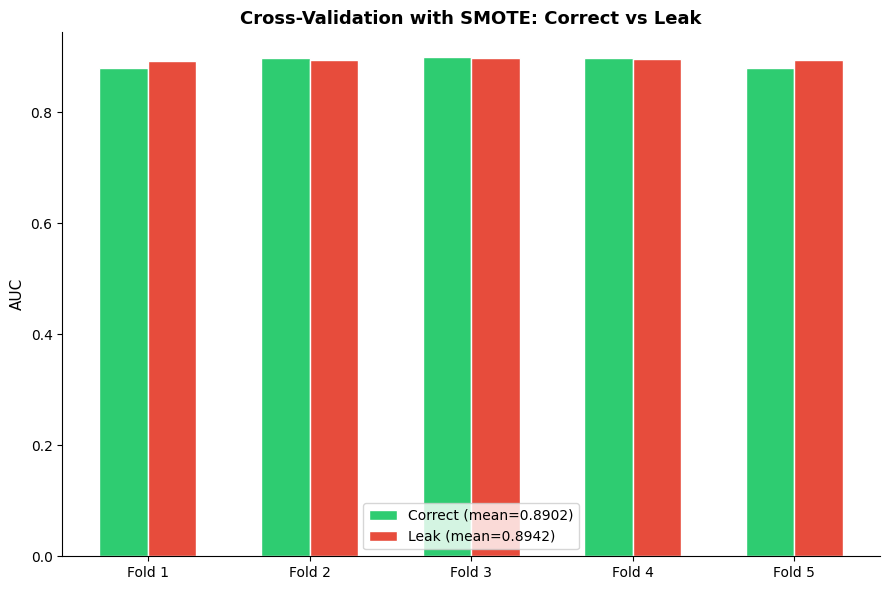

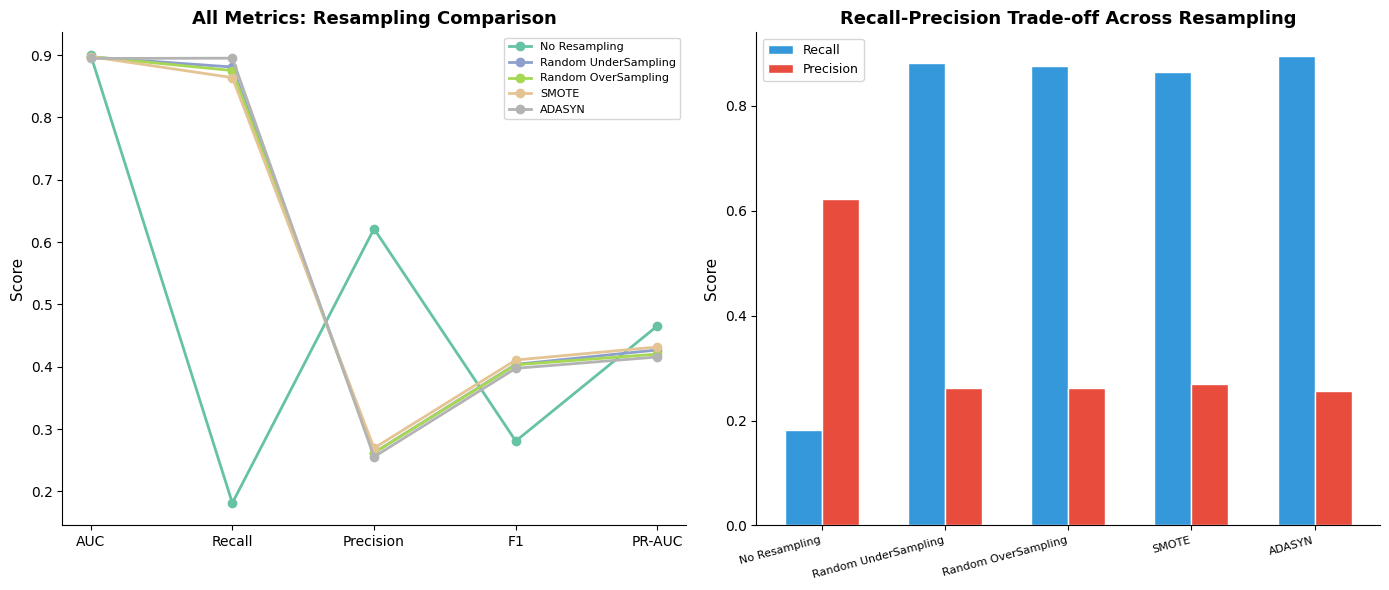

In [23]:
# 图: CV 对比
fig, ax = plt.subplots(figsize=(9, 6))
x_folds = np.arange(5) + 1
width = 0.3
ax.bar(x_folds - width/2, cv_correct_aucs, width, color='#2ecc71', edgecolor='white',
       label=f'Correct (mean={np.mean(cv_correct_aucs):.4f})')
ax.bar(x_folds + width/2, cv_leak_aucs, width, color='#e74c3c', edgecolor='white',
       label=f'Leak (mean={np.mean(cv_leak_aucs):.4f})')
ax.set_xticks(x_folds)
ax.set_xticklabels([f'Fold {i}' for i in x_folds])
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('Cross-Validation with SMOTE: Correct vs Leak',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13f_cv_smote.png"), dpi=150, bbox_inches='tight')
# plt.close()
print("\n  [图] 13f_cv_smote.png → CV SMOTE 对比已保存")

# Combined visual: all SMOTE variants performance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
metrics_plot = ['AUC', 'Recall', 'Precision', 'F1', 'PR-AUC']
x_plot = np.arange(len(metrics_plot))
for i, r in enumerate(resample_results):
    vals = [r[m] for m in metrics_plot]
    ax.plot(x_plot, vals, 'o-', color=colors_radar[i], linewidth=2,
            label=r['Method'], markersize=6)
ax.set_xticks(x_plot)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Metrics: Resampling Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax = axes[1]
methods_show = [r['Method'] for r in resample_results]
recalls = [r['Recall'] for r in resample_results]
precisions = [r['Precision'] for r in resample_results]
x_b = np.arange(len(methods_show))
width_b = 0.3
ax.bar(x_b - width_b/2, recalls, width_b, color='#3498db', edgecolor='white', label='Recall')
ax.bar(x_b + width_b/2, precisions, width_b, color='#e74c3c', edgecolor='white', label='Precision')
ax.set_xticks(x_b)
ax.set_xticklabels(methods_show, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Recall-Precision Trade-off Across Resampling',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "13g_resampling_all_metrics.png"),
            dpi=150, bbox_inches='tight')
# plt.close()
print("  [图] 13g_resampling_all_metrics.png → 全指标对比已保存")